# Beer Expert Panel Synthetic Augmentation — Improved Experiment (v2)
## 6 Methods + Improved Validation + Utility + Augmentation Gain (4090 eGPU)

**목표:** 고차원·소량(High-dimensional Small Data) 환경에서  
생성 데이터가 (1) **분포(Distribution)** 와 (2) **의존성(Dependency; 관계 구조)** 을 보존하는지 확인하고,  
(3) **예측 성능 향상(증강 효과; augmentation gain)** 이 실제로 있는지 검증합니다.

---

## 데이터 (전문가 패널만 사용)
- `Supplementary File S1`: 화학 성분 X (`acetaldehyde` ~ `sulfur_sum`)
- `Supplementary File S4`: 전문가 관능평가 Y (`A_malt_all` ~ `overall`)
- 일반인 리뷰(RateBeer)는 사용하지 않습니다.

---

## 6가지 생성 방법
1) 부트스트랩(복원추출; **Bootstrapping**)  
2) 커널 밀도 추정(**KDE**) — (독립 KDE: 마진 분포 위주)  
3) 다변량 가우시안 코퓰러(**Gaussian Copula**)  
4) 변분 오토인코더(**VAE**) — GPU/AMP  
5) **CTGAN** — (설치되어 있으면 사용; 없으면 skip)  
6) 확산모델(표형 DDPM; **TabDDPM**) — **PyTorch 내장 구현(추가 설치 없이 동작)** + GPU/AMP

---

## 검증(평가)

### Phase 1 — 모집단 적합성/구조 보존(Validity & Fidelity)
- **KS-test**: 각 feature별 분포 유사도
- **PCD**(상관 구조 차이):  
  - X–X(화학–화학) 상관 구조  
  - **X–Y(화학–관능) 상관 구조(추가 개선점)**  
  - **Shrinkage(Ledoit–Wolf)** 로 상관행렬을 안정화해서 N≪D에서도 비교 가능
- **DCR**: 가장 가까운 실제 샘플까지 거리(복제/이상치 점검)

### Phase 2 — 유용성(Utility) & 증강 효과(Augmentation Gain)
- **TSTR**(Train on Synthetic, Test on Real): 합성만으로 학습 → 실제로 테스트  
- **TRTR**(Train on Real, Test on Real): 실제만으로 학습 → 실제로 테스트(기준선)  
- **TR+TS → TR test**: (실제+합성) 학습 → 실제 테스트 (**증강 효과**)

**Downstream predictor(다운스트림 예측기 = 실제 예측 모델)**  
- (권장) 트리 기반 그래디언트 부스팅(**Gradient Boosting**) : 논문에서 전반적으로 강한 계열 citeturn3view0turn2view3  
- (추가) Torch MLP (GPU) : 비교용

---

## 실행 팁(시간이 없을 때)
- 먼저 `FAST_MODE=True`로 빠르게 1회 전체 파이프라인이 도는지 확인  
- 그 다음 epoch/샘플 수를 늘려 최종 실험 수행

## 0) 경로/출력 폴더 + Run ID(현재시간)
- Windows 경로: `C:\Users\eys63\Desktop\맥주데이터실험\data`
- 결과는 `outputs/RUN_ID/` 아래에 저장됩니다.

In [1]:

from pathlib import Path
from datetime import datetime
import sys, platform, json

DATA_DIR = Path(r"C:\Users\eys63\Desktop\맥주데이터실험\data")
XLSX_PATH = DATA_DIR / "Supplemental Files and Figure source files.xlsx"

# fallback: notebook folder
if not XLSX_PATH.exists():
    alt = Path("Supplemental Files and Figure source files.xlsx")
    if alt.exists():
        XLSX_PATH = alt

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_ROOT = DATA_DIR / "outputs/gpt"
OUT_ROOT.mkdir(parents=True, exist_ok=True)
RUN_DIR = OUT_ROOT / RUN_ID
RUN_DIR.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version)
print("Platform:", platform.platform())
print("XLSX_PATH:", XLSX_PATH, "| exists:", XLSX_PATH.exists())
print("RUN_ID:", RUN_ID)
print("RUN_DIR:", RUN_DIR)

Python: 3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]
Platform: Windows-10-10.0.26200-SP0
XLSX_PATH: C:\Users\eys63\Desktop\맥주데이터실험\data\Supplemental Files and Figure source files.xlsx | exists: True
RUN_ID: 20260121_045736
RUN_DIR: C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\gpt\20260121_045736


## 1) Imports + CUDA/AMP (4090 eGPU)

In [2]:

import os, math, time, random
import numpy as np
import pandas as pd

from scipy import stats
from scipy.stats import norm

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.covariance import LedoitWolf
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.neighbors import NearestNeighbors

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import cloudpickle

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE =", DEVICE)
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM(GB):", torch.cuda.get_device_properties(0).total_memory / 1e9)

USE_AMP = (DEVICE.type == "cuda")
AMP_DTYPE = torch.bfloat16 if (USE_AMP and torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16
SCALER = torch.cuda.amp.GradScaler(enabled=(USE_AMP and AMP_DTYPE == torch.float16))
print("USE_AMP =", USE_AMP, "| AMP_DTYPE =", AMP_DTYPE, "| GradScaler enabled =", SCALER.is_enabled())

DEVICE = cuda
GPU: NVIDIA GeForce RTX 4090
VRAM(GB): 25.756696576
USE_AMP = True | AMP_DTYPE = torch.bfloat16 | GradScaler enabled = False


C:\Users\eys63\AppData\Local\Temp\ipykernel_5336\704555109.py:46: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  SCALER = torch.cuda.amp.GradScaler(enabled=(USE_AMP and AMP_DTYPE == torch.float16))


## 2) 데이터 로드 (S1 + S4) 및 컬럼 슬라이싱
- X: `acetaldehyde` ~ `sulfur_sum`
- Y: `A_malt_all` ~ `overall`
- join key: `beer_id`

In [3]:

xls = pd.ExcelFile(XLSX_PATH)

chem  = xls.parse("Supplementary File S1")
panel = xls.parse("Supplementary File S4")

assert chem["beer_id"].is_unique
assert panel["beer_id"].is_unique

chem  = chem.set_index("beer_id")
panel = panel.set_index("beer_id")

META_COLS = [c for c in ["beer", "tasting_category_fine"] if c in chem.columns]

def slice_range_columns(cols, start, end):
    cols = list(cols)
    if (start not in cols) or (end not in cols):
        raise KeyError(f"Column range not found: {start}..{end}")
    i0, i1 = cols.index(start), cols.index(end)
    if i0 <= i1:
        return cols[i0:i1+1]
    return cols[i1:i0+1]

X_COLS = slice_range_columns(chem.columns, "acetaldehyde", "sulfur_sum")
Y_COLS = slice_range_columns(panel.columns, "A_malt_all", "overall")

df = chem[META_COLS + X_COLS].join(panel[Y_COLS], how="inner")

print("Merged df:", df.shape)
print("X dim:", len(X_COLS), "| Y dim:", len(Y_COLS))
df.head(2)

Merged df: (250, 283)
X dim: 231 | Y dim: 50


,beer,tasting_category_fine,acetaldehyde,CS2,DES,DMS,ethyl_2.methyl_butyrate,ethyl_acetate,ethyl_decanoate,ethyl_hexanoate,...,coriander,clove,lactic,acetic,barnyard,alcohol,aftertaste,body,co2,overall
beer_id,,,,,,,,,,,,,,,,,,,,,
5410228202929,10,Low/No alcohol,-0.641741,-2.146292,-1.905267,0.046211,-3.19552,-0.599350,-1.975309,-2.476904,...,0.783631,2.828355,-0.162975,-0.282149,-0.35729,-1.807336,-1.682733,-0.630386,-1.043431,-0.467852
5410783031019,86,Low/No alcohol,-0.174824,-2.146292,-0.257098,0.347241,-3.19552,-0.507254,-1.755970,-2.175874,...,-0.213168,-0.225153,-0.314574,-0.282149,-0.35729,-1.974904,-1.456136,-1.380574,-0.408753,-0.994806


## 3) 전처리 (Impute + Scaling) + Stratified split(스타일 층화)
- 논문도 **맥주 스타일 기준으로 층화 분할**을 사용 citeturn2view3turn3view0  
- 생성 모델 학습은 수치 안정성을 위해 [0,1] 스케일에서 수행합니다.

In [4]:

class BeerPreprocessor:
    def __init__(self, mode="minmax_only"):
        assert mode in ["minmax_only", "shift_log1p_minmax"]
        self.mode = mode
        self.imputer_x = SimpleImputer(strategy="mean")
        self.imputer_y = SimpleImputer(strategy="mean")
        self.scaler_x = MinMaxScaler()
        self.scaler_y = MinMaxScaler()
        self.shift_ = None
        self.fitted_ = False

    def fit(self, X, y):
        X_imp = self.imputer_x.fit_transform(X)
        y_imp = self.imputer_y.fit_transform(y)

        if self.mode == "shift_log1p_minmax":
            min_per_col = np.min(X_imp, axis=0)
            self.shift_ = np.where(min_per_col < 0, -min_per_col, 0.0).astype(np.float32)
            X2 = np.log1p(np.clip(X_imp + self.shift_, 0, None))
        else:
            self.shift_ = np.zeros(X_imp.shape[1], dtype=np.float32)
            X2 = X_imp

        self.scaler_x.fit(X2)
        self.scaler_y.fit(y_imp)

        self.fitted_ = True
        return self

    def transform_X(self, X):
        assert self.fitted_
        X_imp = self.imputer_x.transform(X)
        if self.mode == "shift_log1p_minmax":
            X2 = np.log1p(np.clip(X_imp + self.shift_, 0, None))
        else:
            X2 = X_imp
        return self.scaler_x.transform(X2).astype(np.float32)

    def transform_y(self, y):
        assert self.fitted_
        y_imp = self.imputer_y.transform(y)
        return self.scaler_y.transform(y_imp).astype(np.float32)

    def inverse_transform_X(self, Xs):
        assert self.fitted_
        X2 = self.scaler_x.inverse_transform(Xs)
        if self.mode == "shift_log1p_minmax":
            X_imp = np.expm1(X2) - self.shift_
        else:
            X_imp = X2
        return X_imp.astype(np.float32)

    def inverse_transform_y(self, ys):
        assert self.fitted_
        return self.scaler_y.inverse_transform(ys).astype(np.float32)

MODE = "minmax_only"  # "minmax_only" or "shift_log1p_minmax"
pre = BeerPreprocessor(mode=MODE)

X_raw = df[X_COLS].to_numpy(dtype=np.float32)
y_raw = df[Y_COLS].to_numpy(dtype=np.float32)

strat = df["tasting_category_fine"].astype(str).values if "tasting_category_fine" in df.columns else None

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=strat
)

pre.fit(X_train, y_train)
X_train_s = pre.transform_X(X_train)
X_test_s  = pre.transform_X(X_test)
y_train_s = pre.transform_y(y_train)
y_test_s  = pre.transform_y(y_test)

print("Train:", X_train_s.shape, y_train_s.shape, "| Test:", X_test_s.shape, y_test_s.shape)

# Save preprocessor and split
with open(RUN_DIR / f"{RUN_ID}__preprocessor.pkl", "wb") as f:
    cloudpickle.dump(pre, f)

np.savez(RUN_DIR / f"{RUN_ID}__split_arrays.npz",
         X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)

Train: (200, 231) (200, 50) | Test: (50, 231) (50, 50)


## 4) Phase 1 지표 구현: KS / PCD(XX, XY) / DCR
### 4-1) KS-test (분포 유사도)
각 feature별로 진짜 vs 합성 분포가 얼마나 다른지 확인합니다.

### 4-2) PCD (상관 구조 차이)
- Ledoit–Wolf 수축(Ledoit–Wolf shrinkage)으로 상관행렬을 안정화 citeturn1view1  
- X–X(화학–화학) 뿐 아니라 **X–Y(화학–관능) 블록도 함께 비교(개선점)**

### 4-3) DCR (최단거리)
- 너무 가까우면 복제/암기 의심
- 너무 멀면 이상치 의심

In [5]:

def ks_test_featurewise(X_real, X_syn, feature_names=None):
    D = X_real.shape[1]
    if feature_names is None:
        feature_names = [f"f_{i:03d}" for i in range(D)]
    rows = []
    for j in range(D):
        r = X_real[:, j]
        s = X_syn[:, j]
        if np.allclose(r, r[0]) and np.allclose(s, s[0]):
            ks_stat, pval = 0.0, 1.0
        else:
            res = stats.ks_2samp(r, s, alternative="two-sided", mode="auto")
            ks_stat, pval = float(res.statistic), float(res.pvalue)
        rows.append((feature_names[j], ks_stat, pval))
    df = pd.DataFrame(rows, columns=["feature", "ks_stat", "p_value"])
    summary = {
        "ks_mean": float(df["ks_stat"].mean()),
        "ks_median": float(df["ks_stat"].median()),
        "p_pass_rate_0.05": float((df["p_value"] > 0.05).mean()),
    }
    return df, summary

def _rank_transform_cols(A):
    # Spearman-style: rank each column
    A = np.asarray(A)
    R = np.zeros_like(A, dtype=np.float32)
    for j in range(A.shape[1]):
        R[:, j] = stats.rankdata(A[:, j], method="average").astype(np.float32)
    # normalize ranks to [0,1]
    R = (R - 0.5) / max(1, A.shape[0])
    return R

def corr_shrinkage(A, method="pearson"):
    # A: (n, d)
    if method == "spearman":
        A2 = _rank_transform_cols(A)
    else:
        A2 = A

    A2 = A2 - np.mean(A2, axis=0, keepdims=True)
    lw = LedoitWolf().fit(A2)
    cov = lw.covariance_
    d = np.sqrt(np.clip(np.diag(cov), 1e-12, None))
    C = cov / np.outer(d, d)
    C[np.diag_indices_from(C)] = 1.0
    return np.nan_to_num(C, nan=0.0, posinf=0.0, neginf=0.0)

def frob(A):
    return float(np.linalg.norm(A, ord="fro"))

def pcd_blocks_from_corr(C_real, C_syn, dx, dy):
    # C: (dx+dy, dx+dy)
    Crr_xx = C_real[:dx, :dx]
    Css_xx = C_syn[:dx, :dx]
    Crr_xy = C_real[:dx, dx:dx+dy]
    Css_xy = C_syn[:dx, dx:dx+dy]

    return {
        "pcd_xx_fro": frob(Crr_xx - Css_xx),
        "pcd_xy_fro": frob(Crr_xy - Css_xy),
        "pcd_xx_mean_abs": float(np.mean(np.abs(Crr_xx - Css_xx))),
        "pcd_xy_mean_abs": float(np.mean(np.abs(Crr_xy - Css_xy))),
    }

def dcr_metrics(X_real_s, X_syn_s, use_gpu=True, chunk=2048):
    # syn -> real
    if use_gpu and torch.cuda.is_available():
        Xr = torch.from_numpy(X_real_s).to(DEVICE)
        Xs = torch.from_numpy(X_syn_s).to(DEVICE)
        mins = []
        for i in range(0, Xs.shape[0], chunk):
            part = Xs[i:i+chunk]
            dist = torch.cdist(part, Xr)
            mins.append(dist.min(dim=1).values.detach().cpu())
        d_syn = torch.cat(mins).numpy()
    else:
        nn = NearestNeighbors(n_neighbors=1).fit(X_real_s)
        d_syn, _ = nn.kneighbors(X_syn_s, n_neighbors=1)
        d_syn = d_syn.reshape(-1)

    # real -> real (2nd nn)
    nn2 = NearestNeighbors(n_neighbors=2).fit(X_real_s)
    d_real, _ = nn2.kneighbors(X_real_s, n_neighbors=2)
    d_real = d_real[:, 1]

    thr = float(np.quantile(d_real, 0.05))
    mem_rate = float(np.mean(d_syn < thr))

    return {
        "dcr_syn_mean": float(np.mean(d_syn)),
        "dcr_syn_median": float(np.median(d_syn)),
        "dcr_real_mean": float(np.mean(d_real)),
        "dcr_ratio_mean": float(np.mean(d_syn) / (np.mean(d_real) + 1e-12)),
        "dcr_mem_rate@q05real": mem_rate,
    }

# Precompute real correlation matrices ONCE (for PCD)
dx, dy = X_train.shape[1], y_train.shape[1]
Z_train_for_corr = np.concatenate([pre.imputer_x.transform(X_train), pre.imputer_y.transform(y_train)], axis=1)

C_real_pearson = corr_shrinkage(Z_train_for_corr, method="pearson")
C_real_spearman = corr_shrinkage(Z_train_for_corr, method="spearman")

print("Precomputed C_real (pearson & spearman) shapes:", C_real_pearson.shape, C_real_spearman.shape)

Precomputed C_real (pearson & spearman) shapes: (281, 281) (281, 281)


## 5) Phase 2 평가 구현: TSTR / TRTR / Real+Syn(증강 효과)
### Downstream predictor (다운스트림 예측기) 2종
- **Gradient Boosting (트리 기반)**: `HistGradientBoostingRegressor`를 multi-output으로 래핑  
- **Torch MLP (GPU)**: 비교용

**평가지표**
- 결정계수(**R²**) / 제곱평균제곱근오차(**RMSE**)
- 또한 descriptor(관능 항목)별 점수를 저장하고, synth 방법별 **평균 순위(average rank)** 를 계산합니다.

In [6]:

def r2_rmse_per_target(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    r2_list = []
    rmse_list = []
    for j in range(y_true.shape[1]):
        r2_list.append(r2_score(y_true[:, j], y_pred[:, j]))
        rmse_list.append(math.sqrt(mean_squared_error(y_true[:, j], y_pred[:, j])))
    return np.array(r2_list, dtype=np.float64), np.array(rmse_list, dtype=np.float64)

def summarize_scores(r2_arr, rmse_arr):
    return {
        "r2_mean": float(np.mean(r2_arr)),
        "r2_median": float(np.median(r2_arr)),
        "rmse_mean": float(np.mean(rmse_arr)),
        "rmse_median": float(np.median(rmse_arr)),
    }

class GBMDownstream:
    name = "GBDT"
    def __init__(self, random_state=0):
        base = HistGradientBoostingRegressor(
            loss="squared_error",
            learning_rate=0.05,
            max_depth=6,
            max_iter=600,
            early_stopping=True,
            validation_fraction=0.2,
            random_state=random_state,
        )
        self.model = MultiOutputRegressor(base, n_jobs=-1)

    def fit(self, X, y):
        self.model.fit(X, y)
        return self

    def predict(self, X):
        return self.model.predict(X)

class TorchMLPDownstream:
    name = "MLP"
    def __init__(self, input_dim, output_dim, hidden=(256,128), lr=2e-3, wd=1e-4,
                 max_epochs=400, batch_size=64, patience=50, seed=0):
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.hidden = hidden
        self.lr = lr
        self.wd = wd
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.patience = patience
        self.seed = seed

        layers = []
        d = input_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(0.05)]
            d = h
        layers += [nn.Linear(d, output_dim)]
        self.net = nn.Sequential(*layers).to(DEVICE)

    def fit(self, X, y):
        seed_everything(self.seed)
        Xt = torch.from_numpy(X.astype(np.float32)).to(DEVICE)
        yt = torch.from_numpy(y.astype(np.float32)).to(DEVICE)

        n = Xt.shape[0]
        idx = torch.randperm(n, device=DEVICE)
        n_val = max(1, int(0.2*n))
        val_idx, tr_idx = idx[:n_val], idx[n_val:]
        Xtr, ytr = Xt[tr_idx], yt[tr_idx]
        Xva, yva = Xt[val_idx], yt[val_idx]

        opt = torch.optim.AdamW(self.net.parameters(), lr=self.lr, weight_decay=self.wd)

        best = float("inf")
        best_state = None
        bad = 0
        bs = min(self.batch_size, len(Xtr))

        for epoch in range(1, self.max_epochs+1):
            self.net.train()
            perm = torch.randperm(len(Xtr), device=DEVICE)
            tr_loss = 0.0
            for i in range(0, len(Xtr), bs):
                xb = Xtr[perm[i:i+bs]]
                yb = ytr[perm[i:i+bs]]
                opt.zero_grad(set_to_none=True)

                with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                    pred = self.net(xb)
                    loss = F.mse_loss(pred, yb)

                if SCALER.is_enabled():
                    SCALER.scale(loss).backward()
                    SCALER.step(opt)
                    SCALER.update()
                else:
                    loss.backward()
                    opt.step()

                tr_loss += float(loss.detach()) * len(xb)
            tr_loss /= len(Xtr)

            self.net.eval()
            with torch.no_grad():
                with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                    pred_va = self.net(Xva)
                    va_loss = float(F.mse_loss(pred_va, yva).detach())

            if va_loss < best - 1e-6:
                best = va_loss
                best_state = {k: v.detach().cpu().clone() for k, v in self.net.state_dict().items()}
                bad = 0
            else:
                bad += 1

            if epoch % 50 == 0 or epoch == 1:
                print(f"[MLP-down] epoch {epoch:4d} | train {tr_loss:.6f} | val {va_loss:.6f} | best {best:.6f}")

            if bad >= self.patience:
                print(f"[MLP-down] Early stop at epoch {epoch} (best {best:.6f})")
                break

        if best_state is not None:
            self.net.load_state_dict(best_state)
        return self

    def predict(self, X):
        self.net.eval()
        Xt = torch.from_numpy(X.astype(np.float32)).to(DEVICE)
        with torch.no_grad():
            with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                pred = self.net(Xt).float().cpu().numpy()
        return pred

## 6) 6가지 Synthesizer 구현 + 모델 저장
- CTGAN은 설치되어 있으면 사용하고, 없으면 skip합니다.
- TabDDPM은 **추가 설치 없이** PyTorch로 구현되어 항상 동작합니다.

In [7]:

class BaseSynthesizer:
    name = "Base"
    def fit(self, Xs, ys):
        raise NotImplementedError
    def sample(self, n):
        raise NotImplementedError
    def save(self, path_prefix: Path):
        path = Path(str(path_prefix) + ".pkl")
        with open(path, "wb") as f:
            cloudpickle.dump(self, f)
        return path

class BootstrapSynthesizer(BaseSynthesizer):
    name = "Bootstrapping"
    def __init__(self, seed=0):
        self.seed = seed
        self.rng = np.random.default_rng(seed)
    def fit(self, Xs, ys):
        self.Xs = Xs; self.ys = ys
        return self
    def sample(self, n):
        idx = self.rng.integers(0, len(self.Xs), size=n)
        return self.Xs[idx], self.ys[idx]

In [8]:

from sklearn.neighbors import KernelDensity

class IndependentKDESynthesizer(BaseSynthesizer):
    name = "KDE"
    def __init__(self, bandwidth=0.05, kernel="gaussian", seed=0):
        self.bandwidth = bandwidth
        self.kernel = kernel
        self.seed = seed
        self.rng = np.random.default_rng(seed)

    def fit(self, Xs, ys):
        self.d_x = Xs.shape[1]
        self.d_y = ys.shape[1]
        Z = np.concatenate([Xs, ys], axis=1)
        self.models = []
        self.is_const = []
        self.const_val = []

        for j in range(Z.shape[1]):
            col = Z[:, [j]]
            if np.allclose(col, col[0]):
                self.models.append(None)
                self.is_const.append(True)
                self.const_val.append(float(col[0, 0]))
            else:
                kde = KernelDensity(kernel=self.kernel, bandwidth=self.bandwidth)
                kde.fit(col)
                self.models.append(kde)
                self.is_const.append(False)
                self.const_val.append(0.0)
        return self

    def sample(self, n):
        d = self.d_x + self.d_y
        Zs = np.zeros((n, d), dtype=np.float32)
        for j in range(d):
            if self.is_const[j]:
                Zs[:, j] = self.const_val[j]
            else:
                rs = int(self.rng.integers(0, 1_000_000))
                samp = self.models[j].sample(n_samples=n, random_state=rs)
                Zs[:, j] = samp[:, 0]
        Zs = np.nan_to_num(Zs, nan=0.0, posinf=1.0, neginf=0.0)
        Zs = np.clip(Zs, 0.0, 1.0)
        return Zs[:, :self.d_x], Zs[:, self.d_x:]

In [9]:

def rank_to_u(x):
    n = len(x)
    ranks = stats.rankdata(x, method="average")
    u = (ranks - 0.5) / n
    return np.clip(u, 1e-6, 1-1e-6)

def make_psd_corr(C, eps=1e-6):
    w, V = np.linalg.eigh(C)
    w = np.clip(w, eps, None)
    Cp = (V * w) @ V.T
    d = np.sqrt(np.clip(np.diag(Cp), eps, None))
    Cp = Cp / np.outer(d, d)
    Cp[np.diag_indices_from(Cp)] = 1.0
    return Cp

def safe_quantile(data, q):
    try:
        return np.quantile(data, q, method="linear")
    except TypeError:
        return np.quantile(data, q, interpolation="linear")

class GaussianCopulaSynthesizer(BaseSynthesizer):
    name = "GaussianCopula"
    def __init__(self, seed=0):
        self.seed = seed
        self.rng = np.random.default_rng(seed)

    def fit(self, Xs, ys):
        self.d_x = Xs.shape[1]
        self.d_y = ys.shape[1]
        Z = np.concatenate([Xs, ys], axis=1).astype(np.float64)

        self.is_const = np.zeros(Z.shape[1], dtype=bool)
        self.const_val = np.zeros(Z.shape[1], dtype=np.float64)

        U = np.zeros_like(Z)
        for j in range(Z.shape[1]):
            col = Z[:, j]
            if np.allclose(col, col[0]):
                self.is_const[j] = True
                self.const_val[j] = col[0]
                U[:, j] = 0.5
            else:
                U[:, j] = rank_to_u(col)

        G = norm.ppf(U)

        lw = LedoitWolf().fit(G)
        cov = lw.covariance_
        d = np.sqrt(np.clip(np.diag(cov), 1e-12, None))
        corr = cov / np.outer(d, d)
        corr[np.diag_indices_from(corr)] = 1.0

        self.corr = make_psd_corr(corr)
        self.Z_ref = Z
        return self

    def sample(self, n):
        d = self.d_x + self.d_y
        Gs = self.rng.multivariate_normal(mean=np.zeros(d), cov=self.corr, size=n)
        U = norm.cdf(Gs)

        Zs = np.zeros((n, d), dtype=np.float64)
        for j in range(d):
            if self.is_const[j]:
                Zs[:, j] = self.const_val[j]
            else:
                Zs[:, j] = safe_quantile(self.Z_ref[:, j], U[:, j])

        Zs = np.nan_to_num(Zs, nan=0.0, posinf=1.0, neginf=0.0)
        Zs = np.clip(Zs, 0.0, 1.0).astype(np.float32)
        return Zs[:, :self.d_x], Zs[:, self.d_x:]

In [10]:

class TabularVAE(nn.Module):
    def __init__(self, input_dim, latent_dim=24, hidden=(512, 256), dropout=0.05):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim

        enc = []
        d = input_dim
        for h in hidden:
            enc += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]
            d = h
        self.encoder = nn.Sequential(*enc)
        self.fc_mu = nn.Linear(d, latent_dim)
        self.fc_logvar = nn.Linear(d, latent_dim)

        dec = []
        d = latent_dim
        for h in reversed(hidden):
            dec += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]
            d = h
        dec += [nn.Linear(d, input_dim)]
        self.decoder = nn.Sequential(*dec)

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return torch.sigmoid(self.decoder(z))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar

class VAESynthesizer(BaseSynthesizer):
    name = "VAE"
    def __init__(self, latent_dim=24, hidden=(512,256), beta=0.5, lr=2e-3, wd=1e-4,
                 max_epochs=800, batch_size=64, patience=80, noise_std=0.01, seed=0):
        self.latent_dim = latent_dim
        self.hidden = hidden
        self.beta = beta
        self.lr = lr
        self.wd = wd
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.patience = patience
        self.noise_std = noise_std
        self.seed = seed

    def fit(self, Xs, ys):
        seed_everything(self.seed)
        self.d_x = Xs.shape[1]
        self.d_y = ys.shape[1]
        Z = np.concatenate([Xs, ys], axis=1).astype(np.float32)
        Zt = torch.from_numpy(Z).to(DEVICE)

        n = Zt.shape[0]
        idx = torch.randperm(n, device=DEVICE)
        n_val = max(1, int(0.2*n))
        val_idx = idx[:n_val]
        tr_idx  = idx[n_val:]
        Ztr, Zva = Zt[tr_idx], Zt[val_idx]

        self.model = TabularVAE(Z.shape[1], latent_dim=self.latent_dim, hidden=self.hidden).to(DEVICE)
        opt = torch.optim.AdamW(self.model.parameters(), lr=self.lr, weight_decay=self.wd)

        def loss_fn(x, x_hat, mu, logvar):
            recon = F.mse_loss(x_hat, x, reduction="mean")
            kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
            return recon + self.beta*kld

        best = float("inf")
        best_state = None
        bad = 0
        bs = min(self.batch_size, len(Ztr))

        for epoch in range(1, self.max_epochs+1):
            self.model.train()
            perm = torch.randperm(len(Ztr), device=DEVICE)
            tr_loss = 0.0
            for i in range(0, len(Ztr), bs):
                batch = Ztr[perm[i:i+bs]]
                if self.noise_std > 0:
                    batch_in = torch.clamp(batch + self.noise_std*torch.randn_like(batch), 0.0, 1.0)
                else:
                    batch_in = batch

                opt.zero_grad(set_to_none=True)
                with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                    x_hat, mu, logvar = self.model(batch_in)
                    loss = loss_fn(batch, x_hat, mu, logvar)

                if SCALER.is_enabled():
                    SCALER.scale(loss).backward()
                    SCALER.step(opt)
                    SCALER.update()
                else:
                    loss.backward()
                    opt.step()

                tr_loss += float(loss.detach())*len(batch)
            tr_loss /= len(Ztr)

            self.model.eval()
            with torch.no_grad():
                with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                    x_hat, mu, logvar = self.model(Zva)
                    va_loss = float(loss_fn(Zva, x_hat, mu, logvar).detach())

            if va_loss < best - 1e-6:
                best = va_loss
                best_state = {k: v.detach().cpu().clone() for k, v in self.model.state_dict().items()}
                bad = 0
            else:
                bad += 1

            if epoch % 50 == 0 or epoch == 1:
                print(f"[VAE] epoch {epoch:4d} | train {tr_loss:.6f} | val {va_loss:.6f} | best {best:.6f}")

            if bad >= self.patience:
                print(f"[VAE] Early stop at epoch {epoch} (best {best:.6f})")
                break

        if best_state is not None:
            self.model.load_state_dict(best_state)
        return self

    def sample(self, n):
        self.model.eval()
        with torch.no_grad():
            z = torch.randn((n, self.latent_dim), device=DEVICE)
            with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                out = self.model.decode(z)
        Zs = out.float().clamp(0,1).cpu().numpy()
        return Zs[:, :self.d_x], Zs[:, self.d_x:]

    def save(self, path_prefix: Path):
        path = Path(str(path_prefix) + ".pt")
        torch.save({
            "name": self.name,
            "config": {
                "latent_dim": self.latent_dim,
                "hidden": self.hidden,
                "beta": self.beta,
                "lr": self.lr,
                "wd": self.wd,
                "max_epochs": self.max_epochs,
                "batch_size": self.batch_size,
                "patience": self.patience,
                "noise_std": self.noise_std,
                "seed": self.seed,
            },
            "d_x": getattr(self, "d_x", None),
            "d_y": getattr(self, "d_y", None),
            "state_dict": self.model.state_dict(),
        }, path)
        return path

### CTGAN (옵션)
- 환경에 `sdv` 또는 `ctgan`이 설치되어 있으면 실행됩니다.
- 없으면 해당 모델은 status=missing 처리됩니다.

In [11]:

class CTGANSynthesizerWrapper(BaseSynthesizer):
    name = "CTGAN"
    def __init__(self, epochs=200, batch_size=500, seed=0, enable_gpu=True):
        self.epochs = epochs
        self.batch_size = batch_size
        self.seed = seed
        self.enable_gpu = enable_gpu

    def fit(self, Xs, ys):
        self.d_x = Xs.shape[1]
        self.d_y = ys.shape[1]
        Z = np.concatenate([Xs, ys], axis=1)
        self.cols = [f"col_{i:03d}" for i in range(Z.shape[1])]
        df = pd.DataFrame(Z, columns=self.cols)

        # Prefer SDV
        try:
            from sdv.single_table import CTGANSynthesizer
            from sdv.metadata import SingleTableMetadata
            meta = SingleTableMetadata()
            meta.detect_from_dataframe(df)
            self.model = CTGANSynthesizer(
                metadata=meta,
                epochs=self.epochs,
                batch_size=self.batch_size,
                verbose=True,
                enable_gpu=(self.enable_gpu and torch.cuda.is_available()),
            )
            self.model.fit(df)
            self.backend = "sdv"
            return self
        except Exception as e_sdv:
            self.backend = None
            self.sdv_error = str(e_sdv)

        # Fallback: ctgan package
        try:
            from ctgan import CTGAN
            self.model = CTGAN(
                epochs=self.epochs,
                batch_size=self.batch_size,
                verbose=True,
                cuda=(self.enable_gpu and torch.cuda.is_available()),
            )
            self.model.fit(df, discrete_columns=[])
            self.backend = "ctgan"
            return self
        except Exception as e_ctgan:
            raise ImportError(f"CTGAN requires 'sdv' or 'ctgan'. sdv_error={self.sdv_error} ctgan_error={e_ctgan}")

    def sample(self, n):
        if self.backend == "sdv":
            df_syn = self.model.sample(num_rows=n)
        else:
            df_syn = self.model.sample(n)
        Zs = df_syn[self.cols].to_numpy(dtype=np.float32)
        Zs = np.nan_to_num(Zs, nan=0.0, posinf=1.0, neginf=0.0)
        Zs = np.clip(Zs, 0.0, 1.0)
        return Zs[:, :self.d_x], Zs[:, self.d_x:]

    def save(self, path_prefix: Path):
        path = Path(str(path_prefix) + ".pkl")
        if hasattr(self, "model") and hasattr(self.model, "save"):
            try:
                self.model.save(filepath=str(path))
            except TypeError:
                self.model.save(str(path))
            return path
        with open(path, "wb") as f:
            cloudpickle.dump(self, f)
        return path

### TabDDPM (내장 PyTorch 구현)
- 추가 설치 없이 동작하도록 PyTorch로 구현합니다.
- 빠르게 돌리려면 `timesteps`와 `max_epochs`를 줄이세요.

In [12]:

class SinusoidalTimeEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        device = t.device
        if half <= 0:
            return torch.zeros((t.shape[0], self.dim), device=device)
        emb_scale = math.log(10000) / (half - 1) if half > 1 else 0.0
        freqs = torch.exp(torch.arange(half, device=device) * -emb_scale)
        args = t.float()[:, None] * freqs[None, :]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)
        if self.dim % 2 == 1:
            emb = torch.cat([emb, torch.zeros((t.shape[0], 1), device=device)], dim=1)
        return emb

class TabDDPMDenoiser(nn.Module):
    def __init__(self, data_dim, hidden_dim=512, time_dim=128, n_layers=3, dropout=0.0):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmb(time_dim),
            nn.Linear(time_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.fc_in = nn.Linear(data_dim, hidden_dim)
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout))
            for _ in range(n_layers)
        ])
        self.fc_out = nn.Linear(hidden_dim, data_dim)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        h = self.fc_in(x) + t_emb
        for layer in self.layers:
            h = layer(h) + t_emb
        return self.fc_out(h)

def linear_beta_schedule(T, beta_start=1e-4, beta_end=0.02, device=DEVICE):
    return torch.linspace(beta_start, beta_end, T, device=device)

class TabDDPMSynthesizer(BaseSynthesizer):
    name = "TabDDPM"
    def __init__(self, timesteps=100, hidden_dim=512, time_dim=128, n_layers=3, dropout=0.0,
                 lr=2e-4, weight_decay=1e-4, max_epochs=2500, batch_size=64, patience=200,
                 grad_clip=1.0, seed=0):
        self.timesteps = timesteps
        self.hidden_dim = hidden_dim
        self.time_dim = time_dim
        self.n_layers = n_layers
        self.dropout = dropout
        self.lr = lr
        self.weight_decay = weight_decay
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.patience = patience
        self.grad_clip = grad_clip
        self.seed = seed

    def _prepare_schedule(self):
        T = self.timesteps
        self.betas = linear_beta_schedule(T, device=DEVICE)
        self.alphas = 1.0 - self.betas
        self.alpha_bar = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alpha_bar = torch.sqrt(self.alpha_bar)
        self.sqrt_one_minus_alpha_bar = torch.sqrt(1.0 - self.alpha_bar)

    def fit(self, Xs, ys):
        seed_everything(self.seed)
        self.d_x = Xs.shape[1]
        self.d_y = ys.shape[1]
        Z = np.concatenate([Xs, ys], axis=1).astype(np.float32)

        # [0,1] -> [-1,1]
        Zm = Z * 2.0 - 1.0
        Zt = torch.from_numpy(Zm).to(DEVICE)

        n = Zt.shape[0]
        idx = torch.randperm(n, device=DEVICE)
        n_val = max(1, int(0.2*n))
        val_idx = idx[:n_val]
        tr_idx  = idx[n_val:]
        Ztr, Zva = Zt[tr_idx], Zt[val_idx]

        self.model = TabDDPMDenoiser(
            data_dim=Zt.shape[1],
            hidden_dim=self.hidden_dim,
            time_dim=self.time_dim,
            n_layers=self.n_layers,
            dropout=self.dropout,
        ).to(DEVICE)

        self._prepare_schedule()
        opt = torch.optim.AdamW(self.model.parameters(), lr=self.lr, weight_decay=self.weight_decay)

        best = float("inf")
        best_state = None
        bad = 0
        bs = min(self.batch_size, len(Ztr))

        for epoch in range(1, self.max_epochs+1):
            self.model.train()
            perm = torch.randperm(len(Ztr), device=DEVICE)
            tr_loss = 0.0

            for i in range(0, len(Ztr), bs):
                x0 = Ztr[perm[i:i+bs]]
                B = x0.shape[0]
                t = torch.randint(0, self.timesteps, (B,), device=DEVICE)

                eps = torch.randn_like(x0)
                sqrt_ab = self.sqrt_alpha_bar[t][:, None]
                sqrt_1m = self.sqrt_one_minus_alpha_bar[t][:, None]
                xt = sqrt_ab * x0 + sqrt_1m * eps

                opt.zero_grad(set_to_none=True)
                with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                    eps_hat = self.model(xt, t)
                    loss = F.mse_loss(eps_hat, eps, reduction="mean")

                if SCALER.is_enabled():
                    SCALER.scale(loss).backward()
                    if self.grad_clip is not None:
                        SCALER.unscale_(opt)
                        torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.grad_clip)
                    SCALER.step(opt)
                    SCALER.update()
                else:
                    loss.backward()
                    if self.grad_clip is not None:
                        torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.grad_clip)
                    opt.step()

                tr_loss += float(loss.detach()) * B

            tr_loss /= len(Ztr)

            # validation
            self.model.eval()
            with torch.no_grad():
                Bv = Zva.shape[0]
                tv = torch.randint(0, self.timesteps, (Bv,), device=DEVICE)
                epsv = torch.randn_like(Zva)
                sqrt_abv = self.sqrt_alpha_bar[tv][:, None]
                sqrt_1mv = self.sqrt_one_minus_alpha_bar[tv][:, None]
                xtv = sqrt_abv * Zva + sqrt_1mv * epsv
                with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                    eps_hat_v = self.model(xtv, tv)
                    va_loss = float(F.mse_loss(eps_hat_v, epsv, reduction="mean").detach())

            if va_loss < best - 1e-6:
                best = va_loss
                best_state = {k: v.detach().cpu().clone() for k, v in self.model.state_dict().items()}
                bad = 0
            else:
                bad += 1

            if epoch % 200 == 0 or epoch == 1:
                print(f"[TabDDPM] epoch {epoch:5d} | train {tr_loss:.6f} | val {va_loss:.6f} | best {best:.6f}")

            if bad >= self.patience:
                print(f"[TabDDPM] Early stop at epoch {epoch} (best {best:.6f})")
                break

        if best_state is not None:
            self.model.load_state_dict(best_state)
        return self

    @torch.no_grad()
    def sample(self, n):
        self.model.eval()
        D = self.d_x + self.d_y
        x = torch.randn((n, D), device=DEVICE)

        for t in reversed(range(self.timesteps)):
            tb = torch.full((n,), t, device=DEVICE, dtype=torch.long)
            with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                eps_hat = self.model(x, tb)

            beta_t = self.betas[t]
            alpha_t = self.alphas[t]
            alpha_bar_t = self.alpha_bar[t]
            sqrt_one_minus_ab = torch.sqrt(1.0 - alpha_bar_t)

            mu = (1.0 / torch.sqrt(alpha_t)) * (x - (beta_t / sqrt_one_minus_ab) * eps_hat)

            if t > 0:
                alpha_bar_prev = self.alpha_bar[t-1]
                posterior_var = beta_t * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar_t)
                x = mu + torch.sqrt(posterior_var) * torch.randn_like(x)
            else:
                x = mu

        Zs = (x + 1.0) / 2.0
        Zs = Zs.float().clamp(0.0, 1.0).cpu().numpy().astype(np.float32)
        return Zs[:, :self.d_x], Zs[:, self.d_x:]

    def save(self, path_prefix: Path):
        path = Path(str(path_prefix) + ".pt")
        torch.save({
            "name": self.name,
            "config": {
                "timesteps": self.timesteps,
                "hidden_dim": self.hidden_dim,
                "time_dim": self.time_dim,
                "n_layers": self.n_layers,
                "dropout": self.dropout,
                "lr": self.lr,
                "weight_decay": self.weight_decay,
                "max_epochs": self.max_epochs,
                "batch_size": self.batch_size,
                "patience": self.patience,
                "grad_clip": self.grad_clip,
                "seed": self.seed,
            },
            "d_x": getattr(self, "d_x", None),
            "d_y": getattr(self, "d_y", None),
            "state_dict": self.model.state_dict(),
        }, path)
        return path

## 7) 메인 실험 루프 (FAST_MODE 지원) + 파일 저장
- 각 생성 방법별로:
  - 모델 학습 → 모델 저장
  - 합성 샘플 생성 → 합성 샘플 저장(선택)
  - Phase1 평가(KS/PCD/DCR)
  - Phase2 평가(TSTR/TRTR/증강)
  - descriptor(관능 항목)별 점수 저장 + 평균 순위 계산용 데이터 축적

In [13]:

FAST_MODE = True  # <-- 시간이 없으면 True로 먼저 전체 파이프라인 점검

# sampling size
N_SYNTH = 2000 if FAST_MODE else 5000

# model budgets (fast)
VAE_EPOCHS = 300 if FAST_MODE else 800
TABDDPM_EPOCHS = 800 if FAST_MODE else 2500
TABDDPM_TIMESTEPS = 60 if FAST_MODE else 100
CTGAN_EPOCHS = 50 if FAST_MODE else 200

SAVE_SYNTH_SCALED = False  # 필요하면 True로
USE_GPU_FOR_DCR = True

# save config
run_cfg = dict(
    RUN_ID=RUN_ID,
    MODE=MODE,
    FAST_MODE=FAST_MODE,
    N_SYNTH=N_SYNTH,
    VAE_EPOCHS=VAE_EPOCHS,
    TABDDPM_EPOCHS=TABDDPM_EPOCHS,
    TABDDPM_TIMESTEPS=TABDDPM_TIMESTEPS,
    CTGAN_EPOCHS=CTGAN_EPOCHS,
)
with open(RUN_DIR / f"{RUN_ID}__config.json", "w", encoding="utf-8") as f:
    json.dump(run_cfg, f, ensure_ascii=False, indent=2)

print("Saved config:", RUN_DIR / f"{RUN_ID}__config.json")

Saved config: C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\gpt\20260121_045736\20260121_045736__config.json


In [14]:

# Define synthesizers (6 methods)
synths = [
    BootstrapSynthesizer(seed=0),
    IndependentKDESynthesizer(bandwidth=0.05, seed=0),
    GaussianCopulaSynthesizer(seed=0),
    VAESynthesizer(seed=0, max_epochs=VAE_EPOCHS),
    CTGANSynthesizerWrapper(epochs=CTGAN_EPOCHS, batch_size=500, seed=0, enable_gpu=True),
    TabDDPMSynthesizer(seed=0, timesteps=TABDDPM_TIMESTEPS, max_epochs=TABDDPM_EPOCHS),
]
print("Synthesizers:", [s.name for s in synths])

# Downstream predictors (2 types)
downstreams = [
    ("GBDT", lambda: GBMDownstream(random_state=0)),
    ("MLP",  lambda: TorchMLPDownstream(input_dim=X_train_s.shape[1], output_dim=y_train_s.shape[1], seed=0)),
]
print("Downstream predictors:", [d[0] for d in downstreams])

Synthesizers: ['Bootstrapping', 'KDE', 'GaussianCopula', 'VAE', 'CTGAN', 'TabDDPM']
Downstream predictors: ['GBDT', 'MLP']


In [15]:

# TRTR baseline per downstream predictor (computed once)
trtr_baselines = {}

for dname, make_model in downstreams:
    print("\n=== TRTR baseline:", dname, "===")
    mdl = make_model()
    t0 = time.time()
    mdl.fit(X_train_s, y_train_s)
    pred_s = mdl.predict(X_test_s)
    pred_s = np.clip(pred_s, 0.0, 1.0)
    pred = pre.inverse_transform_y(pred_s)
    r2_arr, rmse_arr = r2_rmse_per_target(y_test, pred)
    trtr_baselines[dname] = dict(
        r2_arr=r2_arr, rmse_arr=rmse_arr,
        summary=summarize_scores(r2_arr, rmse_arr),
    )
    print(trtr_baselines[dname]["summary"])

# Save TRTR per-descriptor
for dname in trtr_baselines:
    out = pd.DataFrame({
        "descriptor": Y_COLS,
        "r2": trtr_baselines[dname]["r2_arr"],
        "rmse": trtr_baselines[dname]["rmse_arr"],
    })
    out.to_csv(RUN_DIR / f"{RUN_ID}__TRTR__{dname}__per_descriptor.csv", index=False)


=== TRTR baseline: GBDT ===
{'r2_mean': 0.17773576736450195, 'r2_median': 0.13343843817710876, 'rmse_mean': 0.5201249194714918, 'rmse_median': 0.5123277733389192}

=== TRTR baseline: MLP ===


C:\Users\eys63\AppData\Local\Temp\ipykernel_5336\1411071368.py:90: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
C:\Users\eys63\AppData\Local\Temp\ipykernel_5336\1411071368.py:107: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):


[MLP-down] epoch    1 | train 0.098967 | val 0.046178 | best 0.046178
[MLP-down] epoch   50 | train 0.015273 | val 0.023402 | best 0.022313
[MLP-down] Early stop at epoch 89 (best 0.022313)
{'r2_mean': 0.12633716702461242, 'r2_median': 0.07859337329864502, 'rmse_mean': 0.5397204738312029, 'rmse_median': 0.5379081804866848}


C:\Users\eys63\AppData\Local\Temp\ipykernel_5336\1411071368.py:133: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):


In [16]:

results = []
perdesc_rows = []  # long format storage: model, downstream, regime, descriptor, r2, rmse

for syn in synths:
    print("\n" + "="*100)
    print("SYNTH:", syn.name)

    row = {
        "synth": syn.name,
        "status": "ok",
        "fit_sec": None,
        "sample_sec": None,
        "model_path": None,
        "n_synth": N_SYNTH,
    }

    try:
        # fit
        t0 = time.time()
        syn.fit(X_train_s, y_train_s)
        row["fit_sec"] = float(time.time() - t0)

        # save model
        model_path = syn.save(RUN_DIR / f"{RUN_ID}__{syn.name}__model")
        row["model_path"] = str(model_path)

        # sample
        t1 = time.time()
        Xs_syn, ys_syn = syn.sample(N_SYNTH)
        row["sample_sec"] = float(time.time() - t1)

        # Optionally save synthetic scaled
        if SAVE_SYNTH_SCALED:
            Zs = np.concatenate([Xs_syn, ys_syn], axis=1)
            syn_cols = [f"X_{c}" for c in X_COLS] + [f"Y_{c}" for c in Y_COLS]
            pd.DataFrame(Zs, columns=syn_cols).to_csv(
                RUN_DIR / f"{RUN_ID}__{syn.name}__synthetic_scaled.csv", index=False
            )

        # ---------- Phase 1 ----------
        # KS on original X
        X_syn_orig = pre.inverse_transform_X(Xs_syn)
        ks_df, ks_sum = ks_test_featurewise(X_train, X_syn_orig, feature_names=X_COLS)
        ks_df.to_csv(RUN_DIR / f"{RUN_ID}__{syn.name}__KS.csv", index=False)
        row.update(ks_sum)

        # PCD (pearson & spearman) on imputed original space
        X_syn_imp = pre.imputer_x.transform(X_syn_orig)
        y_syn_orig = pre.inverse_transform_y(ys_syn)
        y_syn_imp = pre.imputer_y.transform(y_syn_orig)

        Z_syn_for_corr = np.concatenate([X_syn_imp, y_syn_imp], axis=1)

        C_syn_pearson = corr_shrinkage(Z_syn_for_corr, method="pearson")
        C_syn_spearman = corr_shrinkage(Z_syn_for_corr, method="spearman")

        pcd_p = pcd_blocks_from_corr(C_real_pearson, C_syn_pearson, dx=dx, dy=dy)
        pcd_s = pcd_blocks_from_corr(C_real_spearman, C_syn_spearman, dx=dx, dy=dy)

        row["pcd_xx_fro_pearson"] = pcd_p["pcd_xx_fro"]
        row["pcd_xy_fro_pearson"] = pcd_p["pcd_xy_fro"]
        row["pcd_xx_fro_spearman"] = pcd_s["pcd_xx_fro"]
        row["pcd_xy_fro_spearman"] = pcd_s["pcd_xy_fro"]

        # DCR in scaled X
        dcr = dcr_metrics(X_train_s, Xs_syn, use_gpu=USE_GPU_FOR_DCR)
        row.update(dcr)

        # ---------- Phase 2 ----------
        # TSTR and AUG (Real+Syn) for each downstream predictor
        for dname, make_model in downstreams:
            # TSTR
            mdl = make_model()
            mdl.fit(Xs_syn, ys_syn)
            pred_s = np.clip(mdl.predict(X_test_s), 0.0, 1.0)
            pred = pre.inverse_transform_y(pred_s)
            r2_arr, rmse_arr = r2_rmse_per_target(y_test, pred)
            summ = summarize_scores(r2_arr, rmse_arr)

            row[f"tstr_{dname}_r2_mean"] = summ["r2_mean"]
            row[f"tstr_{dname}_rmse_mean"] = summ["rmse_mean"]

            for j, desc in enumerate(Y_COLS):
                perdesc_rows.append({
                    "synth": syn.name, "downstream": dname, "regime": "TSTR",
                    "descriptor": desc, "r2": float(r2_arr[j]), "rmse": float(rmse_arr[j])
                })

            # AUG: train on (real train + synthetic)
            X_aug = np.concatenate([X_train_s, Xs_syn], axis=0)
            y_aug = np.concatenate([y_train_s, ys_syn], axis=0)

            mdl2 = make_model()
            mdl2.fit(X_aug, y_aug)
            pred_s2 = np.clip(mdl2.predict(X_test_s), 0.0, 1.0)
            pred2 = pre.inverse_transform_y(pred_s2)
            r2_arr2, rmse_arr2 = r2_rmse_per_target(y_test, pred2)
            summ2 = summarize_scores(r2_arr2, rmse_arr2)

            row[f"aug_{dname}_r2_mean"] = summ2["r2_mean"]
            row[f"aug_{dname}_rmse_mean"] = summ2["rmse_mean"]

            # augmentation gain vs TRTR (mean)
            row[f"aug_gain_{dname}_r2_mean"] = float(summ2["r2_mean"] - trtr_baselines[dname]["summary"]["r2_mean"])
            row[f"aug_gain_{dname}_rmse_mean"] = float(summ2["rmse_mean"] - trtr_baselines[dname]["summary"]["rmse_mean"])

            for j, desc in enumerate(Y_COLS):
                perdesc_rows.append({
                    "synth": syn.name, "downstream": dname, "regime": "AUG",
                    "descriptor": desc, "r2": float(r2_arr2[j]), "rmse": float(rmse_arr2[j])
                })

    except Exception as e:
        row["status"] = f"ERROR: {type(e).__name__}: {e}"

    results.append(row)

results_df = pd.DataFrame(results)
results_df


SYNTH: Bootstrapping


Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\eys63\anaconda3\envs\use_gpu\lib\threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "c:\Users\eys63\anaconda3\envs\use_gpu\lib\threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\eys63\anaconda3\envs\use_gpu\lib\subprocess.py", line 1515, in _readerthread
    buffer.append(fh.read())
  File "c:\Users\eys63\anaconda3\envs\use_gpu\lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc0 in position 4: invalid start byte
C:\Users\eys63\AppData\Local\Temp\ipykernel_5336\1411071368.py:90: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
C:\Users\eys63\AppData\Local\Temp\ipykernel_5336\14110713

[MLP-down] epoch    1 | train 0.041001 | val 0.026901 | best 0.026901
[MLP-down] epoch   50 | train 0.003482 | val 0.002188 | best 0.002104
[MLP-down] epoch  100 | train 0.002255 | val 0.001084 | best 0.000992
[MLP-down] epoch  150 | train 0.001856 | val 0.000829 | best 0.000683
[MLP-down] epoch  200 | train 0.001729 | val 0.000629 | best 0.000580
[MLP-down] epoch  250 | train 0.001637 | val 0.000575 | best 0.000533
[MLP-down] epoch  300 | train 0.001652 | val 0.000578 | best 0.000493
[MLP-down] Early stop at epoch 325 (best 0.000493)
[MLP-down] epoch    1 | train 0.040232 | val 0.027143 | best 0.027143


C:\Users\eys63\AppData\Local\Temp\ipykernel_5336\1411071368.py:133: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
C:\Users\eys63\AppData\Local\Temp\ipykernel_5336\1411071368.py:90: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
C:\Users\eys63\AppData\Local\Temp\ipykernel_5336\1411071368.py:107: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):


[MLP-down] epoch   50 | train 0.003281 | val 0.001794 | best 0.001787
[MLP-down] epoch  100 | train 0.002314 | val 0.001099 | best 0.000917
[MLP-down] epoch  150 | train 0.001941 | val 0.000702 | best 0.000702
[MLP-down] epoch  200 | train 0.001781 | val 0.000664 | best 0.000609
[MLP-down] epoch  250 | train 0.001810 | val 0.000690 | best 0.000557
[MLP-down] Early stop at epoch 269 (best 0.000557)

SYNTH: KDE


...

[MLP-down] epoch    1 | train 0.142359 | val 0.113193 | best 0.113193
[MLP-down] epoch   50 | train 0.045186 | val 0.053311 | best 0.052791
[MLP-down] Early stop at epoch 88 (best 0.052791)
[MLP-down] epoch    1 | train 0.130646 | val 0.108125 | best 0.108125


C:\Users\eys63\AppData\Local\Temp\ipykernel_5336\1411071368.py:133: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
C:\Users\eys63\AppData\Local\Temp\ipykernel_5336\1411071368.py:90: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
C:\Users\eys63\AppData\Local\Temp\ipykernel_5336\1411071368.py:107: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):


[MLP-down] epoch   50 | train 0.041153 | val 0.051038 | best 0.050088
[MLP-down] Early stop at epoch 92 (best 0.050088)


C:\Users\eys63\AppData\Local\Temp\ipykernel_5336\1411071368.py:133: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):


,synth,status,fit_sec,sample_sec,model_path,n_synth,ks_mean,ks_median,p_pass_rate_0.05,pcd_xx_fro_pearson,...,aug_GBDT_r2_mean,aug_GBDT_rmse_mean,aug_gain_GBDT_r2_mean,aug_gain_GBDT_rmse_mean,tstr_MLP_r2_mean,tstr_MLP_rmse_mean,aug_MLP_r2_mean,aug_MLP_rmse_mean,aug_gain_MLP_r2_mean,aug_gain_MLP_rmse_mean
0,Bootstrapping,ok,0.000000,0.000000,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\gp...,2000,0.032850,0.0210,0.930736,0.392771,...,0.076584,0.543195,-0.101152,0.023070,-0.017422,0.581149,-0.042182,0.587880,-0.168519,0.048160
1,KDE,ok,0.082725,0.086546,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\gp...,2000,0.151381,0.1045,0.445887,0.169017,...,0.045716,0.570536,-0.132020,0.050411,-0.029583,0.595376,0.024406,0.577827,-0.101931,0.038107
2,GaussianCopula,ok,0.123845,0.249320,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\gp...,2000,0.032448,0.0200,0.930736,0.666604,...,0.152797,0.523360,-0.024938,0.003235,0.107206,0.539658,0.167394,0.522212,0.041057,-0.017509
3,VAE,ok,3.136944,0.022939,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\gp...,2000,0.540092,0.5230,0.000000,40.656235,...,0.171408,0.519974,-0.006328,-0.000151,-0.057753,0.600796,0.107102,0.547210,-0.019235,0.007489
4,CTGAN,ok,50.437651,2.813931,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\gp...,2000,0.350798,0.3500,0.000000,0.129451,...,0.118948,0.541001,-0.058788,0.020876,-0.424045,0.697202,0.062458,0.557296,-0.063879,0.017575
5,TabDDPM,ok,12.311371,0.102415,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\gp...,2000,0.462011,0.4455,0.000000,1.490016,...,0.076305,0.548361,-0.101431,0.028236,-0.823616,0.729855,-0.182632,0.613945,-0.308969,0.074225


## 8) 결과 저장 + descriptor(관능 항목)별 결과/순위 저장
- `results.csv`: synth별 요약
- `per_descriptor.csv`: descriptor별 점수(긴 형식)
- `rank.csv`: descriptor별 순위를 평균내어 synth 평균 순위(논문 스타일)

In [17]:

# Save summary results
results_path = RUN_DIR / f"{RUN_ID}__results.csv"
results_df.to_csv(results_path, index=False, encoding="utf-8-sig")
print("Saved:", results_path)

# Save per-descriptor long table
perdesc_df = pd.DataFrame(perdesc_rows)
perdesc_path = RUN_DIR / f"{RUN_ID}__per_descriptor_scores.csv"
perdesc_df.to_csv(perdesc_path, index=False, encoding="utf-8-sig")
print("Saved:", perdesc_path)

display(results_df.sort_values(["status", "aug_gain_GBDT_r2_mean"], ascending=[True, False]).head(10))

Saved: C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\gpt\20260121_045736\20260121_045736__results.csv
Saved: C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\gpt\20260121_045736\20260121_045736__per_descriptor_scores.csv


,synth,status,fit_sec,sample_sec,model_path,n_synth,ks_mean,ks_median,p_pass_rate_0.05,pcd_xx_fro_pearson,...,aug_GBDT_r2_mean,aug_GBDT_rmse_mean,aug_gain_GBDT_r2_mean,aug_gain_GBDT_rmse_mean,tstr_MLP_r2_mean,tstr_MLP_rmse_mean,aug_MLP_r2_mean,aug_MLP_rmse_mean,aug_gain_MLP_r2_mean,aug_gain_MLP_rmse_mean
3,VAE,ok,3.136944,0.022939,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\gp...,2000,0.540092,0.5230,0.000000,40.656235,...,0.171408,0.519974,-0.006328,-0.000151,-0.057753,0.600796,0.107102,0.547210,-0.019235,0.007489
2,GaussianCopula,ok,0.123845,0.249320,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\gp...,2000,0.032448,0.0200,0.930736,0.666604,...,0.152797,0.523360,-0.024938,0.003235,0.107206,0.539658,0.167394,0.522212,0.041057,-0.017509
4,CTGAN,ok,50.437651,2.813931,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\gp...,2000,0.350798,0.3500,0.000000,0.129451,...,0.118948,0.541001,-0.058788,0.020876,-0.424045,0.697202,0.062458,0.557296,-0.063879,0.017575
0,Bootstrapping,ok,0.000000,0.000000,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\gp...,2000,0.032850,0.0210,0.930736,0.392771,...,0.076584,0.543195,-0.101152,0.023070,-0.017422,0.581149,-0.042182,0.587880,-0.168519,0.048160
5,TabDDPM,ok,12.311371,0.102415,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\gp...,2000,0.462011,0.4455,0.000000,1.490016,...,0.076305,0.548361,-0.101431,0.028236,-0.823616,0.729855,-0.182632,0.613945,-0.308969,0.074225
1,KDE,ok,0.082725,0.086546,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\gp...,2000,0.151381,0.1045,0.445887,0.169017,...,0.045716,0.570536,-0.132020,0.050411,-0.029583,0.595376,0.024406,0.577827,-0.101931,0.038107


In [18]:

# Compute average rank across descriptors (higher R2 is better)
# We'll do ranks for regime=AUG, downstream=GBDT (main), among synth methods only.
main = perdesc_df[(perdesc_df["regime"]=="AUG") & (perdesc_df["downstream"]=="GBDT")].copy()

if len(main) > 0:
    # pivot: rows=descriptor, cols=synth, values=r2
    piv = main.pivot_table(index="descriptor", columns="synth", values="r2", aggfunc="mean")
    # rank within each descriptor (1=best)
    ranks = piv.rank(axis=1, ascending=False, method="average")
    avg_rank = ranks.mean(axis=0).sort_values()
    rank_df = avg_rank.reset_index()
    rank_df.columns = ["synth", "avg_rank_AUG_GBDT"]
    rank_path = RUN_DIR / f"{RUN_ID}__avg_rank_AUG_GBDT.csv"
    rank_df.to_csv(rank_path, index=False, encoding="utf-8-sig")
    print("Saved:", rank_path)
    display(rank_df)

    # Also compute augmentation gain per descriptor vs TRTR baseline (GBDT)
    trtr_desc = pd.read_csv(RUN_DIR / f"{RUN_ID}__TRTR__GBDT__per_descriptor.csv")
    trtr_map = dict(zip(trtr_desc["descriptor"], trtr_desc["r2"]))

    main["trtr_r2"] = main["descriptor"].map(trtr_map)
    main["r2_gain_vs_trtr"] = main["r2"] - main["trtr_r2"]

    gain_piv = main.pivot_table(index="descriptor", columns="synth", values="r2_gain_vs_trtr", aggfunc="mean")
    gain_rank = gain_piv.rank(axis=1, ascending=False, method="average")
    gain_avg_rank = gain_rank.mean(axis=0).sort_values()

    gain_rank_df = gain_avg_rank.reset_index()
    gain_rank_df.columns = ["synth", "avg_rank_GAIN_AUG_GBDT"]
    gain_rank_path = RUN_DIR / f"{RUN_ID}__avg_rank_GAIN_AUG_GBDT.csv"
    gain_rank_df.to_csv(gain_rank_path, index=False, encoding="utf-8-sig")
    print("Saved:", gain_rank_path)
    display(gain_rank_df)
else:
    print("No per-descriptor data for AUG/GBDT (check status).")

Saved: C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\gpt\20260121_045736\20260121_045736__avg_rank_AUG_GBDT.csv


,synth,avg_rank_AUG_GBDT
0,GaussianCopula,2.54
1,VAE,2.56
2,CTGAN,3.52
3,Bootstrapping,3.80
4,TabDDPM,4.04
5,KDE,4.54


Saved: C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\gpt\20260121_045736\20260121_045736__avg_rank_GAIN_AUG_GBDT.csv


,synth,avg_rank_GAIN_AUG_GBDT
0,GaussianCopula,2.54
1,VAE,2.56
2,CTGAN,3.52
3,Bootstrapping,3.80
4,TabDDPM,4.04
5,KDE,4.54


## 9) 빠른 시각화(선택)
- AUG(GBDT)에서 평균 R² 향상(증강 이득) 비교
- descriptor별 R² 분포 비교(박스플롯)

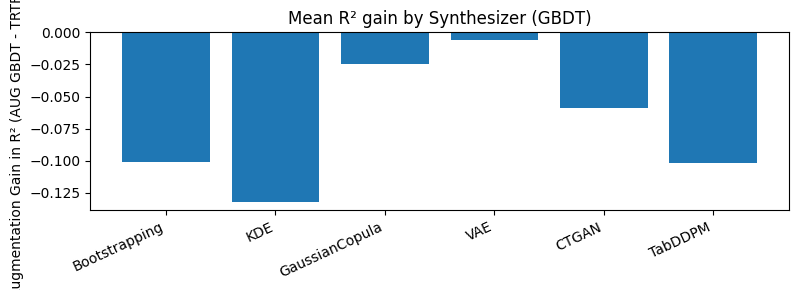

C:\Users\eys63\AppData\Local\Temp\ipykernel_5336\99546598.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=synth_names, showfliers=False)


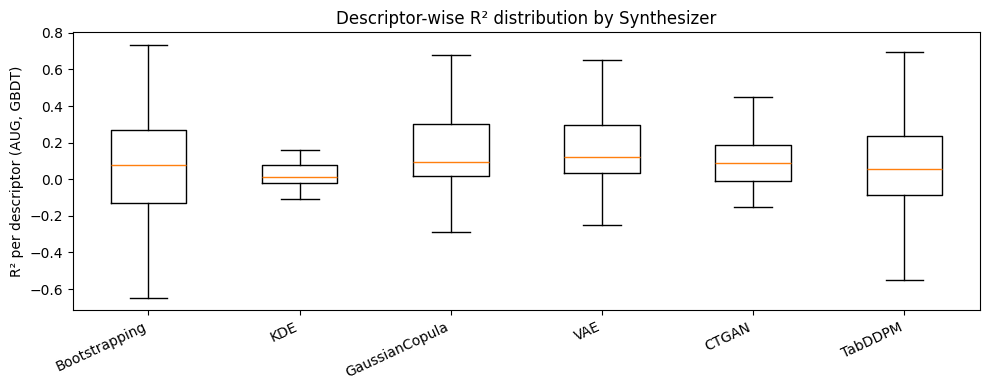

In [19]:

ok = results_df[results_df["status"]=="ok"].copy()
if len(ok) > 0:
    # Augmentation gain (mean R2) by synth
    plt.figure(figsize=(8,3))
    plt.bar(ok["synth"], ok["aug_gain_GBDT_r2_mean"])
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("Augmentation Gain in R² (AUG GBDT - TRTR GBDT)")
    plt.title("Mean R² gain by Synthesizer (GBDT)")
    plt.tight_layout()
    plt.show()

    # Boxplot of per-descriptor R2 for AUG/GBDT
    main = perdesc_df[(perdesc_df["regime"]=="AUG") & (perdesc_df["downstream"]=="GBDT")]
    if len(main) > 0:
        synth_names = list(main["synth"].unique())
        data = [main[main["synth"]==s]["r2"].values for s in synth_names]
        plt.figure(figsize=(10,4))
        plt.boxplot(data, labels=synth_names, showfliers=False)
        plt.xticks(rotation=25, ha="right")
        plt.ylabel("R² per descriptor (AUG, GBDT)")
        plt.title("Descriptor-wise R² distribution by Synthesizer")
        plt.tight_layout()
        plt.show()
else:
    print("No successful runs to plot.")

## 10) (선택) CTGAN 설치
CTGAN이 missing/ERROR로 뜨면 아래 중 하나를 설치하세요.

```bash
pip install sdv
# 또는
pip install ctgan
```

(커널 재시작 후 다시 실행 권장)